# Linear Downsample Cross-Subject Summary

Brainomni is replaced with results from `result_5/linear_downsample_brainomni`; other models still use `result_5/linear_downsample`.


In [1]:
from __future__ import annotations



import json

import math

import re

from pathlib import Path

from statistics import NormalDist



import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import matplotlib as mpl

from matplotlib.colors import ListedColormap

from matplotlib.patches import Patch

try:

    from IPython.display import display

except Exception:

    def display(value):

        print(value)



try:

    from scipy.stats import binomtest, ttest_1samp

except Exception:

    binomtest = None

    ttest_1samp = None



pd.set_option("display.max_rows", 200)

pd.set_option("display.max_columns", 50)


In [2]:
# -----------------------

# Config


In [3]:
# -----------------------

REPO_ROOT = Path("/benchmark-eeg/5.0_version")

RESULT_ROOT = REPO_ROOT / "result_5" / "linear_downsample"

BRAINOMNI_RESULT_ROOT = REPO_ROOT / "result_5" / "linear_downsample_brainomni"

REFERENCE_CSV = REPO_ROOT / "experiment_tracking" / "experiment_reference.csv"



MODE = "cross_subject"

SEEDS = [42, 10, 5]

MODEL_ORDER = ["brainomni", "labram", "biot", "femba", "neurolm", "cbramod", "neurogpt", "reve", "reve_new", "eegmamba", "bendr"]



ALPHA = 0.05

DISPLAY_AS_PERCENT = True

COLOR_BY = "normalized_gain"  # "accuracy" or "normalized_gain"

INCLUDE_PARTIAL = True



CATEGORY_COLORS = {

    "Type-I": "#E58AD9",

    "Type-II": "#B58BFF",

    "Type-III": "#5FA2F1",

    "Type-IV": "#62C5AE",

    "Type-V": "#FFA06A",

    "Type-VI": "#EF5A83",

    "Type-VII": "#B978D6",

    "": "#BBBBBB",

}



print("RESULT_ROOT:", RESULT_ROOT)

print("BRAINOMNI_RESULT_ROOT:", BRAINOMNI_RESULT_ROOT)

print("REFERENCE_CSV:", REFERENCE_CSV)


RESULT_ROOT: /benchmark-eeg/5.0_version/result_5/linear_downsample
BRAINOMNI_RESULT_ROOT: /benchmark-eeg/5.0_version/result_5/linear_downsample_brainomni
REFERENCE_CSV: /benchmark-eeg/5.0_version/experiment_tracking/experiment_reference.csv


In [4]:
# -----------------------

# Name normalization / fuzzy matching


In [5]:
# -----------------------

def clean(value):

    return "" if value is None or (isinstance(value, float) and np.isnan(value)) else str(value).strip()





def normalize_name(value: str) -> str:

    key = clean(value).lower()

    replacements = {

        "–": "_",

        "—": "_",

        "-": "_",

        " ": "_",

        "（": "(",

        "）": ")",

        "monitering": "monitoring",

        "extraversial": "extraversion",

        "fintuen": "finetune",

    }

    for src, dst in replacements.items():

        key = key.replace(src, dst)

    key = re.sub(r"\([^)]*\)", "", key)

    key = re.sub(r"_balanced$", "", key)

    key = re.sub(r"_old_badscale$", "", key)

    key = re.sub(r"_wsn$", "", key)

    return re.sub(r"[^a-z0-9]+", "", key)





def names_match(query: str, candidate: str) -> bool:

    q = normalize_name(query)

    c = normalize_name(candidate)

    if not q or not c:

        return False

    return q == c or (len(q) >= 5 and q in c) or (len(c) >= 5 and c in q)





def parse_chance(text) -> float | None:

    text = clean(text)

    if "/" not in text:

        return None

    right = text.split("/")[-1].strip()

    m = re.search(r"([0-9]*\.?[0-9]+)", right)

    return float(m.group(1)) if m else None





def result_dataset_from_dir(name: str, mode: str = MODE) -> str:

    marker = f"_{mode}_"

    return name.split(marker, 1)[0] if marker in name else name


def brainomni_dataset_from_dir(name: str, mode: str = MODE) -> str:

    dataset = result_dataset_from_dir(name, mode=mode)

    return re.sub(r"_brainomni$", "", dataset)


In [6]:
# -----------------------

# Load reference table


In [7]:
# -----------------------

ref = pd.read_csv(REFERENCE_CSV)

ref = ref.copy()

ref["dataset_display"] = ref["dataset"].astype(str)

ref["dataset_key"] = ref["dataset_display"].map(normalize_name)

ref["chance"] = ref["bacc_chance"].map(parse_chance)



# Empty cell means this experiment is applicable; N/A means skip.

applicable = ref[ref["linear_downsample_cross"].fillna("").str.upper() != "N/A"].copy()

print("Reference rows:", len(ref))

print("Applicable linear_downsample_cross rows:", len(applicable))

applicable[["category", "dataset_display", "bacc_chance", "chance", "linear_downsample_cross"]].head(20)


Reference rows: 57
Applicable linear_downsample_cross rows: 57


,category,dataset_display,bacc_chance,chance,linear_downsample_cross
0,Type-I,Longitudinal_EEG_Reliability,0.8161 / 0.500,0.500,NaN
1,Type-I,EEGDenoiseNet,0.7439 / 0.500,0.500,NaN
2,Type-II,LEMON_age,0.3429 / 0.333,0.333,NaN
3,Type-II,LEMON_gender,0.7340 / 0.500,0.500,NaN
4,Type-II,LEMON_extraversial,0.6450 / 0.500,0.500,NaN
5,Type-II,HFO,0.7439 / 0.500,0.500,NaN
6,Type-II,TUAB,— / 0.500,0.500,NaN
7,Type-II,TUEP,— / 0.500,0.500,NaN
8,Type-II,TUEV,— / 0.167,0.167,NaN
9,Type-II,TUSL,- / 0.333,0.333,NaN


In [8]:
# -----------------------

# Discover result directories


In [9]:
# -----------------------

result_dirs = []

if RESULT_ROOT.exists():

    for path in RESULT_ROOT.iterdir():

        if not path.is_dir():

            continue

        if f"_{MODE}_" not in path.name:

            continue

        result_dirs.append(path)



result_dir_df = pd.DataFrame({

    "result_dir": result_dirs,

    "result_dir_name": [p.name for p in result_dirs],

    "result_dataset": [result_dataset_from_dir(p.name) for p in result_dirs],

})

result_dir_df["result_key"] = result_dir_df["result_dataset"].map(normalize_name)

print("Discovered result dirs:", len(result_dir_df))

result_dir_df.head()


brainomni_result_dirs = []

if BRAINOMNI_RESULT_ROOT.exists():

    for path in BRAINOMNI_RESULT_ROOT.iterdir():

        if not path.is_dir():

            continue

        if f"_{MODE}_" not in path.name:

            continue

        brainomni_result_dirs.append(path)



brainomni_result_dir_df = pd.DataFrame({

    "result_dir": brainomni_result_dirs,

    "result_dir_name": [p.name for p in brainomni_result_dirs],

    "result_dataset": [brainomni_dataset_from_dir(p.name) for p in brainomni_result_dirs],

})

if not brainomni_result_dir_df.empty:

    brainomni_result_dir_df["result_key"] = brainomni_result_dir_df["result_dataset"].map(normalize_name)

print("Discovered replacement brainomni result dirs:", len(brainomni_result_dir_df))

brainomni_result_dir_df.head()


Discovered result dirs: 59
Discovered replacement brainomni result dirs: 39


,result_dir,result_dir_name,result_dataset,result_key
0,/benchmark-eeg/5.0_version/result_5/linear_dow...,AD65_brainomni_cross_subject_linear_downsample...,AD65,ad65
1,/benchmark-eeg/5.0_version/result_5/linear_dow...,ADHD_brainomni_cross_subject_linear_downsample...,ADHD,adhd
2,/benchmark-eeg/5.0_version/result_5/linear_dow...,Awakening_brainomni_cross_subject_linear_downs...,Awakening,awakening
3,/benchmark-eeg/5.0_version/result_5/linear_dow...,BCIC2A_brainomni_cross_subject_linear_downsamp...,BCIC2A,bcic2a
4,/benchmark-eeg/5.0_version/result_5/linear_dow...,BCIC4_1_brainomni_cross_subject_linear_downsam...,BCIC4_1,bcic41


In [10]:
# -----------------------

# Match reference datasets to result directories


In [11]:
# -----------------------

def choose_result_dir(dataset_display: str, dirs_df: pd.DataFrame = result_dir_df) -> Path | None:

    if dirs_df.empty:

        return None

    exact = dirs_df[dirs_df["result_key"] == normalize_name(dataset_display)]

    if len(exact):

        return exact.iloc[0]["result_dir"]

    fuzzy = dirs_df[dirs_df["result_dataset"].map(lambda x: names_match(dataset_display, x))]

    if len(fuzzy):

        # Prefer linear_downsample suffix, then shortest name.

        tmp = fuzzy.copy()

        tmp["score"] = tmp["result_dir_name"].map(lambda x: (0 if x.endswith("linear_downsample") else 1, len(x), x))

        return tmp.sort_values("score").iloc[0]["result_dir"]

    return None



matched = applicable.copy()

matched["result_dir"] = matched["dataset_display"].map(lambda x: choose_result_dir(x, result_dir_df))

matched["brainomni_result_dir"] = matched["dataset_display"].map(lambda x: choose_result_dir(x, brainomni_result_dir_df))

matched["result_dir_name"] = matched["result_dir"].map(lambda p: p.name if isinstance(p, Path) else "")

matched["brainomni_result_dir_name"] = matched["brainomni_result_dir"].map(lambda p: p.name if isinstance(p, Path) else "")

print("Matched:", matched["result_dir"].notna().sum(), "/", len(matched))

print("Matched replacement brainomni:", matched["brainomni_result_dir"].notna().sum(), "/", len(matched))

matched.loc[matched["result_dir"].isna(), ["category", "dataset_display", "linear_downsample_cross"]].head(50)


Matched: 55 / 57
Matched replacement brainomni: 35 / 57


,category,dataset_display,linear_downsample_cross
0,Type-I,Longitudinal_EEG_Reliability,NaN
1,Type-I,EEGDenoiseNet,NaN


In [12]:
# -----------------------

# Read leaderboard_test.json files


In [13]:
# -----------------------

records = []

for _, row in matched.iterrows():

    source_dirs = {

        "original": row["result_dir"],

        "brainomni_replacement": row["brainomni_result_dir"],

    }

    for source_name, result_dir in source_dirs.items():

        if not isinstance(result_dir, Path):

            continue

        for seed in SEEDS:

            leaderboard = result_dir / f"seed_{seed}_downsample_t40" / "ratio_full" / "leaderboard_test.json"

            if not leaderboard.exists():

                continue

            try:

                data = json.loads(leaderboard.read_text())

            except Exception as exc:

                print("Failed to read", leaderboard, exc)

                continue

            for item in data:

                model = clean(item.get("model")).lower()

                if model not in MODEL_ORDER:

                    continue

                if source_name == "original" and model == "brainomni":

                    continue

                if source_name == "brainomni_replacement" and model != "brainomni":

                    continue

                acc = item.get("test_accuracy")

                if acc is None:

                    continue

                records.append({

                    "category": row["category"],

                    "dataset_display": row["dataset_display"],

                    "dataset_key": row["dataset_key"],

                    "result_dir_name": result_dir.name,

                    "source": source_name,

                    "seed": seed,

                    "model": model,

                    "test_accuracy": float(acc),

                    "chance": row["chance"],

                    "leaderboard_path": str(leaderboard),

                })



long_df = pd.DataFrame(records)

print("Rows:", len(long_df))

print("Datasets with results:", long_df["dataset_display"].nunique() if len(long_df) else 0)

print(long_df.groupby(["source", "model"]).size().unstack(fill_value=0) if len(long_df) else "")

long_df.head()


original_brainomni_records = []

for _, row in matched.iterrows():

    result_dir = row["result_dir"]

    if not isinstance(result_dir, Path):

        continue

    for seed in SEEDS:

        leaderboard = result_dir / f"seed_{seed}_downsample_t40" / "ratio_full" / "leaderboard_test.json"

        if not leaderboard.exists():

            continue

        try:

            data = json.loads(leaderboard.read_text())

        except Exception as exc:

            print("Failed to read original brainomni", leaderboard, exc)

            continue

        for item in data:

            model = clean(item.get("model")).lower()

            if model != "brainomni":

                continue

            acc = item.get("test_accuracy")

            if acc is None:

                continue

            original_brainomni_records.append({

                "category": row["category"],

                "dataset_display": row["dataset_display"],

                "dataset_key": row["dataset_key"],

                "result_dir_name": result_dir.name,

                "source": "original_brainomni",

                "seed": seed,

                "model": model,

                "test_accuracy": float(acc),

                "chance": row["chance"],

                "leaderboard_path": str(leaderboard),

            })

original_brainomni_long_df = pd.DataFrame(original_brainomni_records)

print("Original brainomni rows kept only for comparison:", len(original_brainomni_long_df))

original_brainomni_long_df.head()


Rows: 1474
Datasets with results: 54
model                  bendr  biot  brainomni  cbramod  eegmamba  femba  \
source                                                                    
brainomni_replacement      0     0        102        0         0      0   
original                 152   152          0      152       152    152   

model                  labram  neurogpt  neurolm  reve  
source                                                  
brainomni_replacement       0         0        0     0  
original                  152       152      152   156  
Original brainomni rows kept only for comparison: 152


,category,dataset_display,dataset_key,result_dir_name,source,seed,model,test_accuracy,chance,leaderboard_path
0,Type-II,LEMON_age,lemonage,LEMON_age_cross_subject_linear_downsample,original_brainomni,42,brainomni,0.487813,0.333,/benchmark-eeg/5.0_version/result_5/linear_dow...
1,Type-II,LEMON_age,lemonage,LEMON_age_cross_subject_linear_downsample,original_brainomni,10,brainomni,0.394195,0.333,/benchmark-eeg/5.0_version/result_5/linear_dow...
2,Type-II,LEMON_age,lemonage,LEMON_age_cross_subject_linear_downsample,original_brainomni,5,brainomni,0.494932,0.333,/benchmark-eeg/5.0_version/result_5/linear_dow...
3,Type-II,LEMON_gender,lemongender,LEMON_gender_cross_subject_linear_downsample,original_brainomni,42,brainomni,0.505928,0.500,/benchmark-eeg/5.0_version/result_5/linear_dow...
4,Type-II,LEMON_gender,lemongender,LEMON_gender_cross_subject_linear_downsample,original_brainomni,10,brainomni,0.554075,0.500,/benchmark-eeg/5.0_version/result_5/linear_dow...


In [14]:
# -----------------------

# Estimate test-set size where possible


In [15]:
# -----------------------

def read_manifest_test_n(result_dir: Path, seed: int) -> int | None:

    # Typical split manifests live under indices/<dataset>_indices_cross_subject/seed_*_downsample_t40/split_manifest.json.

    candidates = [

        REPO_ROOT / "indices" / f"{result_dataset_from_dir(result_dir.name)}_indices_cross_subject" / f"seed_{seed}_downsample_t40" / "split_manifest.json",

        REPO_ROOT / "indices" / f"{result_dataset_from_dir(result_dir.name)}_indices_cross_subject" / f"seed_{seed}" / "split_manifest.json",

    ]

    for path in candidates:

        if not path.exists():

            continue

        try:

            m = json.loads(path.read_text())

        except Exception:

            continue

        if "counts" in m and "test" in m["counts"] and "samples" in m["counts"]["test"]:

            return int(m["counts"]["test"]["samples"])

        if "splits" in m and "test" in m["splits"]:

            return len(m["splits"]["test"])

    return None



manifest_records = []

for _, row in matched.dropna(subset=["result_dir"]).iterrows():

    result_dir = row["result_dir"]

    for seed in SEEDS:

        manifest_records.append({

            "dataset_display": row["dataset_display"],

            "seed": seed,

            "n_test": read_manifest_test_n(result_dir, seed),

        })

manifest_df = pd.DataFrame(manifest_records)

manifest_df.head()


,dataset_display,seed,n_test
0,LEMON_age,42,19734
1,LEMON_age,10,19815
2,LEMON_age,5,19868
3,LEMON_gender,42,19734
4,LEMON_gender,10,19734


In [16]:
# -----------------------

# Aggregate seed results and significance


In [17]:
# -----------------------

def one_sided_binom_p(mean_acc, chance, n_test):

    if binomtest is None or pd.isna(mean_acc) or pd.isna(chance) or pd.isna(n_test) or n_test <= 0:

        return None

    k = int(round(float(mean_acc) * int(n_test)))

    k = min(max(k, 0), int(n_test))

    return float(binomtest(k, int(n_test), p=float(chance), alternative="greater").pvalue)





def one_sided_t_p(values, chance):

    values = [float(x) for x in values if not pd.isna(x)]

    if ttest_1samp is None or len(values) < 2 or pd.isna(chance):

        return None

    res = ttest_1samp(values, popmean=float(chance), alternative="greater")

    return float(res.pvalue) if not pd.isna(res.pvalue) else None



summary_rows = []

for (dataset, model), part in long_df.groupby(["dataset_display", "model"], sort=False):

    accs = part["test_accuracy"].astype(float).tolist()

    chance = part["chance"].dropna().iloc[0] if part["chance"].notna().any() else np.nan

    n_tests = manifest_df.loc[manifest_df["dataset_display"] == dataset, "n_test"].dropna().astype(int).tolist()

    n_test = int(round(np.mean(n_tests))) if n_tests else np.nan

    mean_acc = float(np.mean(accs))

    p_binom = one_sided_binom_p(mean_acc, chance, n_test) if not pd.isna(n_test) else None

    p_t = one_sided_t_p(accs, chance)

    p_value = p_binom if p_binom is not None else p_t

    test_method = "binomial" if p_binom is not None else ("seed_ttest" if p_t is not None else "mean_vs_chance")

    significant = (p_value < ALPHA) if p_value is not None else (mean_acc > chance if not pd.isna(chance) else None)

    summary_rows.append({

        "dataset_display": dataset,

        "category": part["category"].iloc[0],

        "model": model,

        "mean_accuracy": mean_acc,

        "std_accuracy": float(np.std(accs, ddof=1)) if len(accs) > 1 else np.nan,

        "n_seed": len(accs),

        "missing_seeds": ",".join(str(s) for s in SEEDS if s not in set(part["seed"].astype(int))),

        "chance": chance,

        "n_test": n_test,

        "p_value": p_value,

        "test_method": test_method,

        "significant": significant,

    })

summary_df = pd.DataFrame(summary_rows)

print(summary_df.shape)

summary_df.head(20)


replacement_brainomni_seed = long_df.loc[long_df["model"] == "brainomni", ["dataset_display", "seed", "test_accuracy"]].rename(

    columns={"test_accuracy": "replacement_accuracy"}

)

original_brainomni_seed = original_brainomni_long_df[["dataset_display", "seed", "test_accuracy"]].rename(

    columns={"test_accuracy": "original_accuracy"}

) if len(original_brainomni_long_df) else pd.DataFrame(columns=["dataset_display", "seed", "original_accuracy"])

brainomni_seed_comparison = original_brainomni_seed.merge(

    replacement_brainomni_seed,

    on=["dataset_display", "seed"],

    how="outer",

)

brainomni_seed_comparison["delta_replacement_minus_original"] = (

    brainomni_seed_comparison["replacement_accuracy"] - brainomni_seed_comparison["original_accuracy"]

)

brainomni_comparison = brainomni_seed_comparison.groupby("dataset_display", dropna=False).agg(

    original_mean_accuracy=("original_accuracy", "mean"),

    replacement_mean_accuracy=("replacement_accuracy", "mean"),

    delta_replacement_minus_original=("delta_replacement_minus_original", "mean"),

    original_n_seed=("original_accuracy", "count"),

    replacement_n_seed=("replacement_accuracy", "count"),

).reset_index()

brainomni_comparison = brainomni_comparison.merge(

    matched[["dataset_display", "category", "result_dir_name", "brainomni_result_dir_name"]],

    on="dataset_display",

    how="left",

)

brainomni_comparison = brainomni_comparison[

    [

        "dataset_display", "category", "original_mean_accuracy", "replacement_mean_accuracy",

        "delta_replacement_minus_original", "original_n_seed", "replacement_n_seed",

        "result_dir_name", "brainomni_result_dir_name",

    ]

].sort_values("delta_replacement_minus_original", ascending=False, na_position="last")

print("Brainomni replacement comparison rows:", len(brainomni_comparison))

brainomni_comparison.head(100)


/root/miniconda3/envs/eeg-bench-new/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/root/miniconda3/envs/eeg-bench-new/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/root/miniconda3/envs/eeg-bench-new/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/root/miniconda3/envs/eeg-bench-new/lib/python3.11/s

(494, 12)
Brainomni replacement comparison rows: 54


/root/miniconda3/envs/eeg-bench-new/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/root/miniconda3/envs/eeg-bench-new/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/root/miniconda3/envs/eeg-bench-new/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/root/miniconda3/envs/eeg-bench-new/lib/python3.11/s

,dataset_display,category,original_mean_accuracy,replacement_mean_accuracy,delta_replacement_minus_original,original_n_seed,replacement_n_seed,result_dir_name,brainomni_result_dir_name
21,HFO,Type-II,0.558232,1.000000,0.441768,3,3,HFO_cross_subject_linear_downsample,HFO_brainomni_cross_subject_linear_downsample_...
1,ADHD,Type-II,0.627453,0.661138,0.033684,3,3,ADHD_cross_subject_linear_downsample,ADHD_brainomni_cross_subject_linear_downsample...
32,MusicEEG,Type-IV,0.489352,0.521759,0.032407,3,3,MusicEEG_cross_subject_linear_downsample,MusicEEG_brainomni_cross_subject_linear_downsa...
31,Monitering-Errp,Type-VI,0.492879,0.514660,0.021780,3,3,MonitoringErrP_cross_subject_linear_downsample,MonitoringErrP_brainomni_cross_subject_linear_...
33,PD31,Type-II,0.406007,0.427487,0.021480,3,3,PD31_cross_subject_linear_downsample,PD31_brainomni_cross_subject_linear_downsample...
44,SSVEP,Type-VI,0.015833,0.037202,0.021369,3,3,SSVEP_cross_subject_linear_downsample,BETA_SSVEP_brainomni_cross_subject_linear_down...
14,DUAL_FREQ_SSVEP,Type-VI,0.050000,0.069792,0.019792,3,3,DUAL_FREQ_SSVEP_cross_subject_linear_downsample,DUAL_FREQ_SSVEP_brainomni_cross_subject_linear...
0,AD65,Type-II,0.462185,0.479966,0.017781,3,3,AD65_cross_subject_linear_downsample,AD65_brainomni_cross_subject_linear_downsample...
28,LEMON_gender,Type-II,0.532188,0.547001,0.014812,3,3,LEMON_gender_cross_subject_linear_downsample,LEMON_gender_brainomni_cross_subject_linear_do...
16,EEG_Mortality_PD,Type-II,0.501494,0.513637,0.012143,3,3,EEG_Mortality_PD_cross_subject_linear_downsample,EEG_Mortality_PD_brainomni_cross_subject_linea...


In [18]:
# -----------------------

# Pivot tables for plotting


In [19]:
# -----------------------

# Keep the reference order, but only datasets that have at least one result unless INCLUDE_PARTIAL=False behavior changes later.

dataset_order = [d for d in matched["dataset_display"].tolist() if d in set(summary_df["dataset_display"])]

category_by_dataset = matched.set_index("dataset_display")["category"].to_dict()

chance_by_dataset = matched.set_index("dataset_display")["chance"].to_dict()



acc_pivot = summary_df.pivot(index="dataset_display", columns="model", values="mean_accuracy").reindex(index=dataset_order, columns=MODEL_ORDER)

sig_pivot = summary_df.pivot(index="dataset_display", columns="model", values="significant").reindex(index=dataset_order, columns=MODEL_ORDER)

seed_pivot = summary_df.pivot(index="dataset_display", columns="model", values="n_seed").reindex(index=dataset_order, columns=MODEL_ORDER)

chance_series = pd.Series(chance_by_dataset).reindex(dataset_order).astype(float)



if COLOR_BY == "normalized_gain":

    color_matrix = acc_pivot.sub(chance_series, axis=0).div(1 - chance_series, axis=0)

    color_label = "Normalized gain over chance"

else:

    color_matrix = acc_pivot.copy()

    color_label = "Test accuracy"



model_mean_acc = acc_pivot.mean(axis=0, skipna=True)

model_avg_rank = acc_pivot.rank(axis=1, ascending=False, method="average").mean(axis=0, skipna=True)



acc_pivot.head()


model,brainomni,labram,biot,femba,neurolm,cbramod,neurogpt,reve,reve_new,eegmamba,bendr
dataset_display,,,,,,,,,,,
Longitudinal_EEG_Reliability,0.731085,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LEMON_age,0.451985,0.438992,0.484163,0.479777,0.402605,0.496931,0.425812,0.475865,NaN,0.332375,0.333333
LEMON_gender,0.547001,0.571009,0.587340,0.568565,0.552786,0.643652,0.544677,0.598737,NaN,0.499321,0.500000
LEMON_extraversial,0.474731,0.508808,0.477952,0.509653,0.517759,0.504320,0.464087,0.505335,NaN,0.503951,0.500000
HFO,1.000000,0.540638,0.585830,0.524820,0.537469,0.563469,0.543885,0.607999,NaN,0.580325,0.500000


In [20]:
# -----------------------

# Heatmap visualization


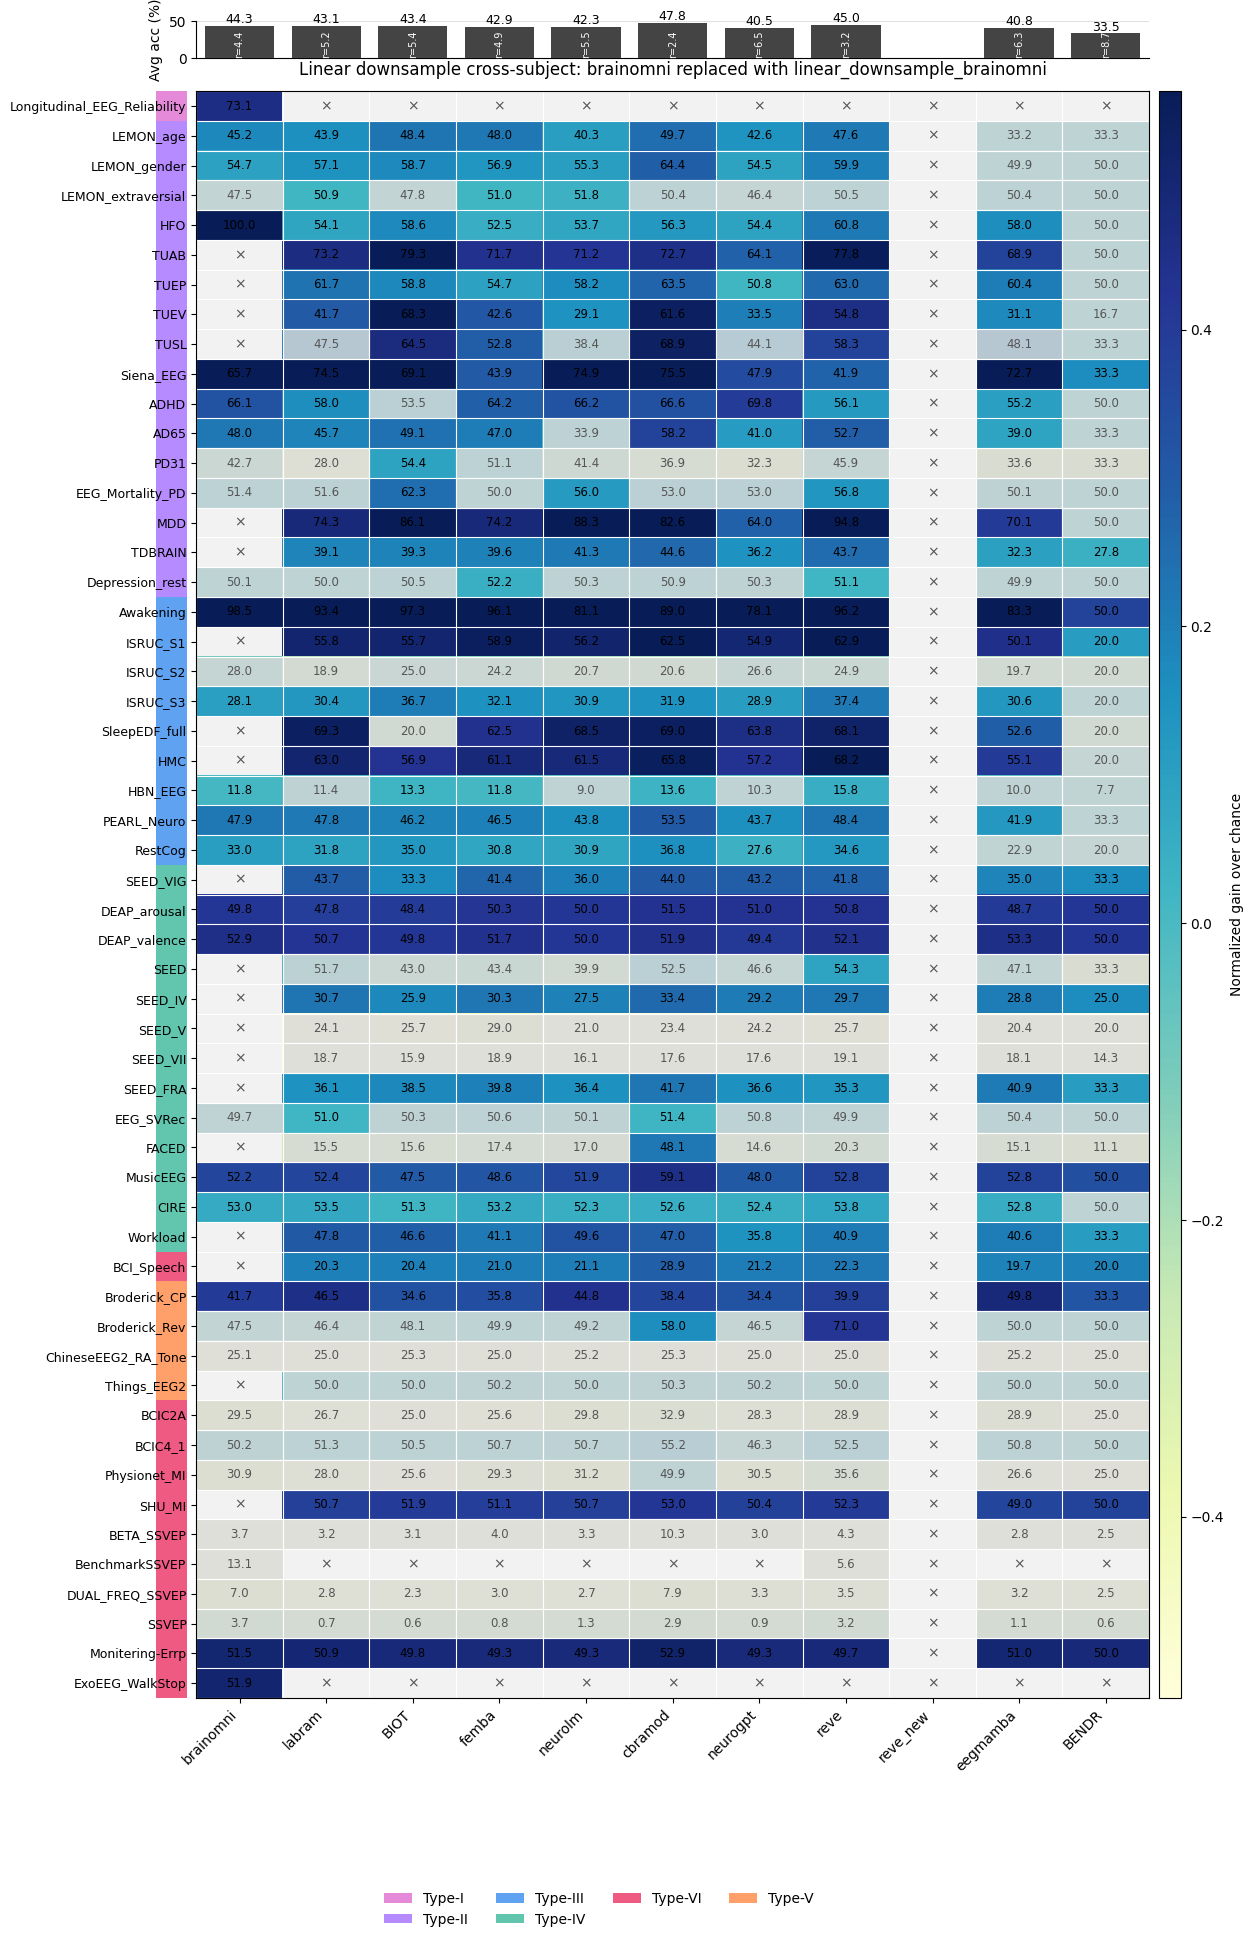

In [21]:
# -----------------------

def format_cell(value):

    if pd.isna(value):

        return "×"

    return f"{value * 100:.1f}" if DISPLAY_AS_PERCENT else f"{value:.3f}"



n_rows, n_cols = acc_pivot.shape

fig_h = max(8, 0.34 * n_rows + 2.6)

fig_w = max(12, 0.85 * n_cols + 4.5)

fig = plt.figure(figsize=(fig_w, fig_h), constrained_layout=False)



# Layout: category strip, heatmap, colorbar, top bar.

gs = fig.add_gridspec(

    nrows=2,

    ncols=3,

    height_ratios=[1.25, n_rows],

    width_ratios=[0.35, n_cols, 0.25],

    hspace=0.04,

    wspace=0.03,

)

ax_top = fig.add_subplot(gs[0, 1])

ax_strip = fig.add_subplot(gs[1, 0])

ax = fig.add_subplot(gs[1, 1])

cax = fig.add_subplot(gs[1, 2])



plot_values = color_matrix.to_numpy(dtype=float)

masked = np.ma.masked_invalid(plot_values)



if COLOR_BY == "normalized_gain":

    vmin = np.nanpercentile(plot_values, 5) if np.isfinite(plot_values).any() else 0

    vmax = np.nanpercentile(plot_values, 95) if np.isfinite(plot_values).any() else 1

    vmin = min(vmin, 0)

    vmax = max(vmax, 0.05)

    cmap = mpl.cm.YlGnBu.copy()

else:

    vmin = np.nanmin(plot_values) if np.isfinite(plot_values).any() else 0

    vmax = np.nanmax(plot_values) if np.isfinite(plot_values).any() else 1

    cmap = mpl.cm.YlGnBu.copy()

cmap.set_bad("#F2F2F2")



im = ax.imshow(masked, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)

cb = fig.colorbar(im, cax=cax)

cb.set_label(color_label, rotation=90)



# Grid lines

ax.set_xticks(np.arange(n_cols))

ax.set_yticks(np.arange(n_rows))

ax.set_xticklabels([m.upper() if m in {"biot", "bendr"} else m for m in MODEL_ORDER], rotation=45, ha="right", fontsize=10)

ax.set_yticklabels(dataset_order, fontsize=9)

ax.set_xticks(np.arange(-.5, n_cols, 1), minor=True)

ax.set_yticks(np.arange(-.5, n_rows, 1), minor=True)

ax.grid(which="minor", color="white", linestyle="-", linewidth=0.8)

ax.tick_params(which="minor", bottom=False, left=False)

ax.set_title("Linear downsample cross-subject: brainomni replaced with linear_downsample_brainomni", pad=12)



# Cell text and gray nonsignificant cells.

for i, dataset in enumerate(dataset_order):

    for j, model in enumerate(MODEL_ORDER):

        value = acc_pivot.loc[dataset, model]

        sig = sig_pivot.loc[dataset, model] if dataset in sig_pivot.index and model in sig_pivot.columns else np.nan

        if pd.isna(value):

            ax.text(j, i, "×", ha="center", va="center", color="#555555", fontsize=10)

            continue

        if sig is False or str(sig).lower() == "false":

            rect = mpl.patches.Rectangle((j - 0.5, i - 0.5), 1, 1, facecolor="#D9D9D9", edgecolor="white", linewidth=0.8, alpha=0.82)

            ax.add_patch(rect)

            color = "#555555"

        else:

            color = "black"

        ax.text(j, i, format_cell(value), ha="center", va="center", color=color, fontsize=8.5)



# Category strip

cat_values = [category_by_dataset.get(d, "") for d in dataset_order]

unique_cats = list(dict.fromkeys(cat_values))

cat_to_idx = {c: i for i, c in enumerate(unique_cats)}

strip_array = np.array([[cat_to_idx[c]] for c in cat_values])

strip_cmap = ListedColormap([CATEGORY_COLORS.get(c, "#BBBBBB") for c in unique_cats])

ax_strip.imshow(strip_array, aspect="auto", cmap=strip_cmap)

ax_strip.set_xticks([])

ax_strip.set_yticks(np.arange(n_rows))

ax_strip.set_yticklabels([])

ax_strip.tick_params(left=False)

for spine in ax_strip.spines.values():

    spine.set_visible(False)



# Top bar: model mean accuracy, with avg rank labels as small secondary information.

bar_values = model_mean_acc.reindex(MODEL_ORDER).to_numpy(dtype=float)

ax_top.bar(np.arange(n_cols), bar_values * (100 if DISPLAY_AS_PERCENT else 1), color="#444444")

ax_top.set_xlim(-0.5, n_cols - 0.5)

ax_top.set_xticks([])

ax_top.set_ylabel("Avg acc" + (" (%)" if DISPLAY_AS_PERCENT else ""))

ax_top.grid(axis="y", color="#E0E0E0", linewidth=0.8)

for j, model in enumerate(MODEL_ORDER):

    y = bar_values[j] * (100 if DISPLAY_AS_PERCENT else 1)

    if np.isfinite(y):

        ax_top.text(j, y, f"{y:.1f}", ha="center", va="bottom", fontsize=9)

        ax_top.text(j, 0, f"r={model_avg_rank[model]:.1f}", ha="center", va="bottom", fontsize=7, color="white", rotation=90)

ax_top.spines[["top", "right"]].set_visible(False)



legend_handles = [Patch(facecolor=CATEGORY_COLORS.get(c, "#BBBBBB"), label=c) for c in unique_cats]

fig.legend(handles=legend_handles, loc="lower center", ncol=min(4, len(legend_handles)), frameon=False, bbox_to_anchor=(0.5, 0.005))



fig.subplots_adjust(left=0.18, right=0.92, top=0.92, bottom=0.12)

plt.show()


In [22]:
# -----------------------

# Tables for inspection inside the notebook only


In [23]:
# -----------------------

display_cols = [

    "dataset_display", "category", "model", "mean_accuracy", "std_accuracy", "n_seed",

    "missing_seeds", "chance", "n_test", "p_value", "test_method", "significant",

]

display(summary_df.sort_values(["dataset_display", "model"])[display_cols].head(100))

display(brainomni_comparison)
# Datasets expected by the reference but not matched to any result directory.

unmatched = matched.loc[matched["result_dir"].isna(), ["category", "dataset_display", "linear_downsample_cross"]]

display(unmatched)

brainomni_unmatched = matched.loc[

    matched["brainomni_result_dir"].isna(),

    ["category", "dataset_display", "linear_downsample_cross"],

]

display(brainomni_unmatched)


,dataset_display,category,model,mean_accuracy,std_accuracy,n_seed,missing_seeds,chance,n_test,p_value,test_method,significant
105,AD65,Type-II,bendr,0.333333,0.000000e+00,3,,0.333,715.0,5.170687e-01,binomial,False
99,AD65,Type-II,biot,0.491391,1.086957e-01,3,,0.333,715.0,2.149231e-18,binomial,True
106,AD65,Type-II,brainomni,0.479966,1.007467e-01,3,,0.333,715.0,3.656445e-16,binomial,True
97,AD65,Type-II,cbramod,0.582404,1.588071e-01,3,,0.333,715.0,3.040487e-42,binomial,True
102,AD65,Type-II,eegmamba,0.389554,7.370282e-02,3,,0.333,715.0,7.624052e-04,binomial,True
103,AD65,Type-II,femba,0.470063,6.807833e-02,3,,0.333,715.0,2.449766e-14,binomial,True
100,AD65,Type-II,labram,0.457227,9.955836e-02,3,,0.333,715.0,3.667008e-12,binomial,True
101,AD65,Type-II,neurogpt,0.409621,8.660902e-02,3,,0.333,715.0,1.064766e-05,binomial,True
104,AD65,Type-II,neurolm,0.338848,3.037502e-02,3,,0.333,715.0,3.919422e-01,binomial,False
98,AD65,Type-II,reve,0.526818,1.875572e-01,3,,0.333,715.0,1.049181e-26,binomial,True


,dataset_display,category,original_mean_accuracy,replacement_mean_accuracy,delta_replacement_minus_original,original_n_seed,replacement_n_seed,result_dir_name,brainomni_result_dir_name
21,HFO,Type-II,0.558232,1.000000,0.441768,3,3,HFO_cross_subject_linear_downsample,HFO_brainomni_cross_subject_linear_downsample_...
1,ADHD,Type-II,0.627453,0.661138,0.033684,3,3,ADHD_cross_subject_linear_downsample,ADHD_brainomni_cross_subject_linear_downsample...
32,MusicEEG,Type-IV,0.489352,0.521759,0.032407,3,3,MusicEEG_cross_subject_linear_downsample,MusicEEG_brainomni_cross_subject_linear_downsa...
31,Monitering-Errp,Type-VI,0.492879,0.514660,0.021780,3,3,MonitoringErrP_cross_subject_linear_downsample,MonitoringErrP_brainomni_cross_subject_linear_...
33,PD31,Type-II,0.406007,0.427487,0.021480,3,3,PD31_cross_subject_linear_downsample,PD31_brainomni_cross_subject_linear_downsample...
44,SSVEP,Type-VI,0.015833,0.037202,0.021369,3,3,SSVEP_cross_subject_linear_downsample,BETA_SSVEP_brainomni_cross_subject_linear_down...
14,DUAL_FREQ_SSVEP,Type-VI,0.050000,0.069792,0.019792,3,3,DUAL_FREQ_SSVEP_cross_subject_linear_downsample,DUAL_FREQ_SSVEP_brainomni_cross_subject_linear...
0,AD65,Type-II,0.462185,0.479966,0.017781,3,3,AD65_cross_subject_linear_downsample,AD65_brainomni_cross_subject_linear_downsample...
28,LEMON_gender,Type-II,0.532188,0.547001,0.014812,3,3,LEMON_gender_cross_subject_linear_downsample,LEMON_gender_brainomni_cross_subject_linear_do...
16,EEG_Mortality_PD,Type-II,0.501494,0.513637,0.012143,3,3,EEG_Mortality_PD_cross_subject_linear_downsample,EEG_Mortality_PD_brainomni_cross_subject_linea...


,category,dataset_display,linear_downsample_cross
0,Type-I,Longitudinal_EEG_Reliability,NaN
1,Type-I,EEGDenoiseNet,NaN


,category,dataset_display,linear_downsample_cross
1,Type-I,EEGDenoiseNet,NaN
6,Type-II,TUAB,NaN
7,Type-II,TUEP,NaN
8,Type-II,TUEV,NaN
9,Type-II,TUSL,NaN
15,Type-II,MDD,NaN
16,Type-II,TDBRAIN,NaN
20,Type-III,ISRUC_S1,NaN
23,Type-III,SleepEDF_full,NaN
24,Type-III,HMC,NaN
